#Spam Email Detection System


---
## Step 1: Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


---
## Step 2: Data Collection


In [ ]:
# Load the CSV dataset
data = pd.read_csv('spam.csv')
print(f"Dataset loaded: {data.shape[0]} rows, {data.shape[1]} columns")
data.head()

Dataset loaded: 5572 rows, 2 columns


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# Check column names
print("Columns:", data.columns.tolist())

Columns: ['Category', 'Message']


In [ ]:
# Dataset info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


Label distribution:
Category
ham     4825
spam     747
Name: count, dtype: int64


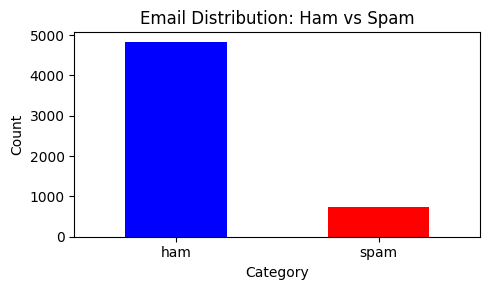

In [ ]:
# Check class distribution
print("Label distribution:")
print(data['Category'].value_counts())

# Visualize distribution
plt.figure(figsize=(5, 3))
data['Category'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title('Email Distribution: Ham vs Spam')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## Step 3: Preprocessing


In [ ]:
# Check for missing values
print("Missing values:")
print(data.isna().sum())

Missing values:
Category    0
Message     0
dtype: int64


In [ ]:
# Drop any missing rows if present
data = data.dropna(subset=['Message', 'Category'])

# Encode labels: spam=1, ham=0
data['Spam'] = data['Category'].apply(lambda x: 1 if x == 'spam' else 0)

print("Label encoding done:")
print(data[['Category', 'Spam']].head(5))

Label encoding done:
  Category  Spam
0      ham     0
1      ham     0
2     spam     1
3      ham     0
4      ham     0


---
## Step 4: Feature Extraction using CountVectorizer


In [ ]:
# Split into features and labels
X = data['Message']
y = data['Spam']

# Train/Test split — 75% train, 25% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

Training samples : 4179
Testing samples  : 1393


---
## Step 5: Model Training — Multinomial Naive Bayes


In [ ]:
# Build the ML Pipeline
# Pipeline Flow: Raw Text → CountVectorizer → MultinomialNB → Prediction
clf = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('nb', MultinomialNB())
])

# Train the model
clf.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


---
## Step 6: Prediction & Evaluation

In [ ]:
# Predict on test set
y_pred = clf.predict(X_test)

# Evaluation Metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("=" * 40)
print("     MODEL EVALUATION RESULTS")
print("=" * 40)
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  Precision : {prec*100:.2f}%")
print(f"  Recall    : {rec*100:.2f}%")
print(f"  F1 Score  : {f1*100:.2f}%")
print("=" * 40)

     MODEL EVALUATION RESULTS
  Accuracy  : 98.85%
  Precision : 97.75%
  Recall    : 93.55%
  F1 Score  : 95.60%


In [ ]:
# Full classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham (Not Spam)', 'Spam']))

Classification Report:
                precision    recall  f1-score   support

Ham (Not Spam)       0.99      1.00      0.99      1207
          Spam       0.98      0.94      0.96       186

      accuracy                           0.99      1393
     macro avg       0.98      0.97      0.97      1393
  weighted avg       0.99      0.99      0.99      1393



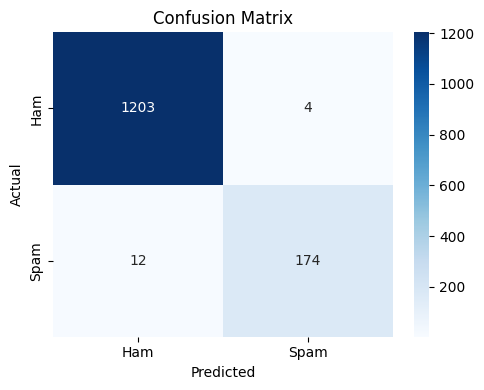

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

---
## Step 7: Test With Custom Emails


In [ ]:
# Test with sample emails (from proposal Section 7)
test_emails = [
    'Sounds great! Are you home now?',
    'Congratulations! You have WON $1,000,000. Call now to claim your prize!',
    'Please review the attached project report before the deadline tomorrow.',
    'FREE OFFER! Buy cheap meds online. No prescription needed. Act NOW!!!'
]

predictions = clf.predict(test_emails)
labels = ['SPAM' if p == 1 else 'HAM (Not Spam)' for p in predictions]

print("Email Classification Results:")
print("-" * 60)
for email, label in zip(test_emails, labels):
    print(f"Email  : {email[:55]}..." if len(email) > 55 else f"Email  : {email}")
    print(f"Result : {label}")
    print("-" * 60)

Email Classification Results:
------------------------------------------------------------
Email  : Sounds great! Are you home now?
Result : HAM (Not Spam)
------------------------------------------------------------
Email  : Congratulations! You have WON $1,000,000. Call now to c...
Result : SPAM
------------------------------------------------------------
Email  : Please review the attached project report before the de...
Result : HAM (Not Spam)
------------------------------------------------------------
Email  : FREE OFFER! Buy cheap meds online. No prescription need...
Result : HAM (Not Spam)
------------------------------------------------------------


In [ ]:
print("Checking Email Classification")
print("-" * 60)

n = int(input("Enter number of emails to test: "))

for i in range(n):
    email = input(f"\nEnter Email {i+1}: ")

    # Predict label using your trained model
    predictions = clf.predict([email])[0]

    if predictions == 1:
        predicted_label = "SPAM"
    else:
        predicted_label = "HAM (Not Spam)"

    expected_label = input("Enter expected label (SPAM/HAM (Not Spam)): ")

    status = "CORRECT" if predicted_label == expected_label else "INCORRECT"

    print("-" * 60)
    print(f"Email {i+1} : {email}")
    print(f"Predicted : {predicted_label}")
    print(f"Expected  : {expected_label}")
    print(f"Status    : {status}")
    print("-" * 60)


Checking Email Classification
------------------------------------------------------------
Enter number of emails to test: 1

Enter Email 1: hi
Enter expected label (SPAM/HAM (Not Spam)): spam
------------------------------------------------------------
Email 1 : hi
Predicted : HAM (Not Spam)
Expected  : spam
Status    : INCORRECT
------------------------------------------------------------
